In [ ]:
# Install Hugging Face libraries for model training
!pip install transformers datasets accelerate --quiet
print("All libraries installed!")

All libraries installed!


In [ ]:
# Hugging Face tools
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from datasets import load_dataset

# Standard libraries
import torch
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print("All imports successful!")

Using device: cpu
All imports successful!


In [ ]:
dataset = load_dataset("Amod/mental_health_counseling_conversations")

print("Dataset loaded!")
print("Splits available:", dataset.keys())
print("Column names:", dataset['train'].column_names)
print("Training samples:", len(dataset['train']))
print()
print("First sample:")
print(dataset['train'][0])

README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

Dataset loaded!
Splits available: dict_keys(['train'])
Column names: ['Context', 'Response']
Training samples: 3512

First sample:
{'Context': "I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone?", 'Response': "If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. \xa0Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their 

In [ ]:
# Look at a few examples
print("Dataset columns:", dataset['train'].column_names)
print()

# Show 3 sample conversations
print("=" * 55)
print("Sample Conversations from EmpatheticDialogues:")
print("=" * 55)

for i in range(3):
    sample = dataset['train'][i]
    print(f"\nExample {i+1}:")
    for col in dataset['train'].column_names:
        print(f"  {col}: {sample[col]}")

Dataset columns: ['Context', 'Response']

Sample Conversations from EmpatheticDialogues:

Example 1:
  Context: I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.
   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.
   How can I change my feeling of being worthless to everyone?
  Response: If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media.  Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so satur

Using column: 'Context' for emotions


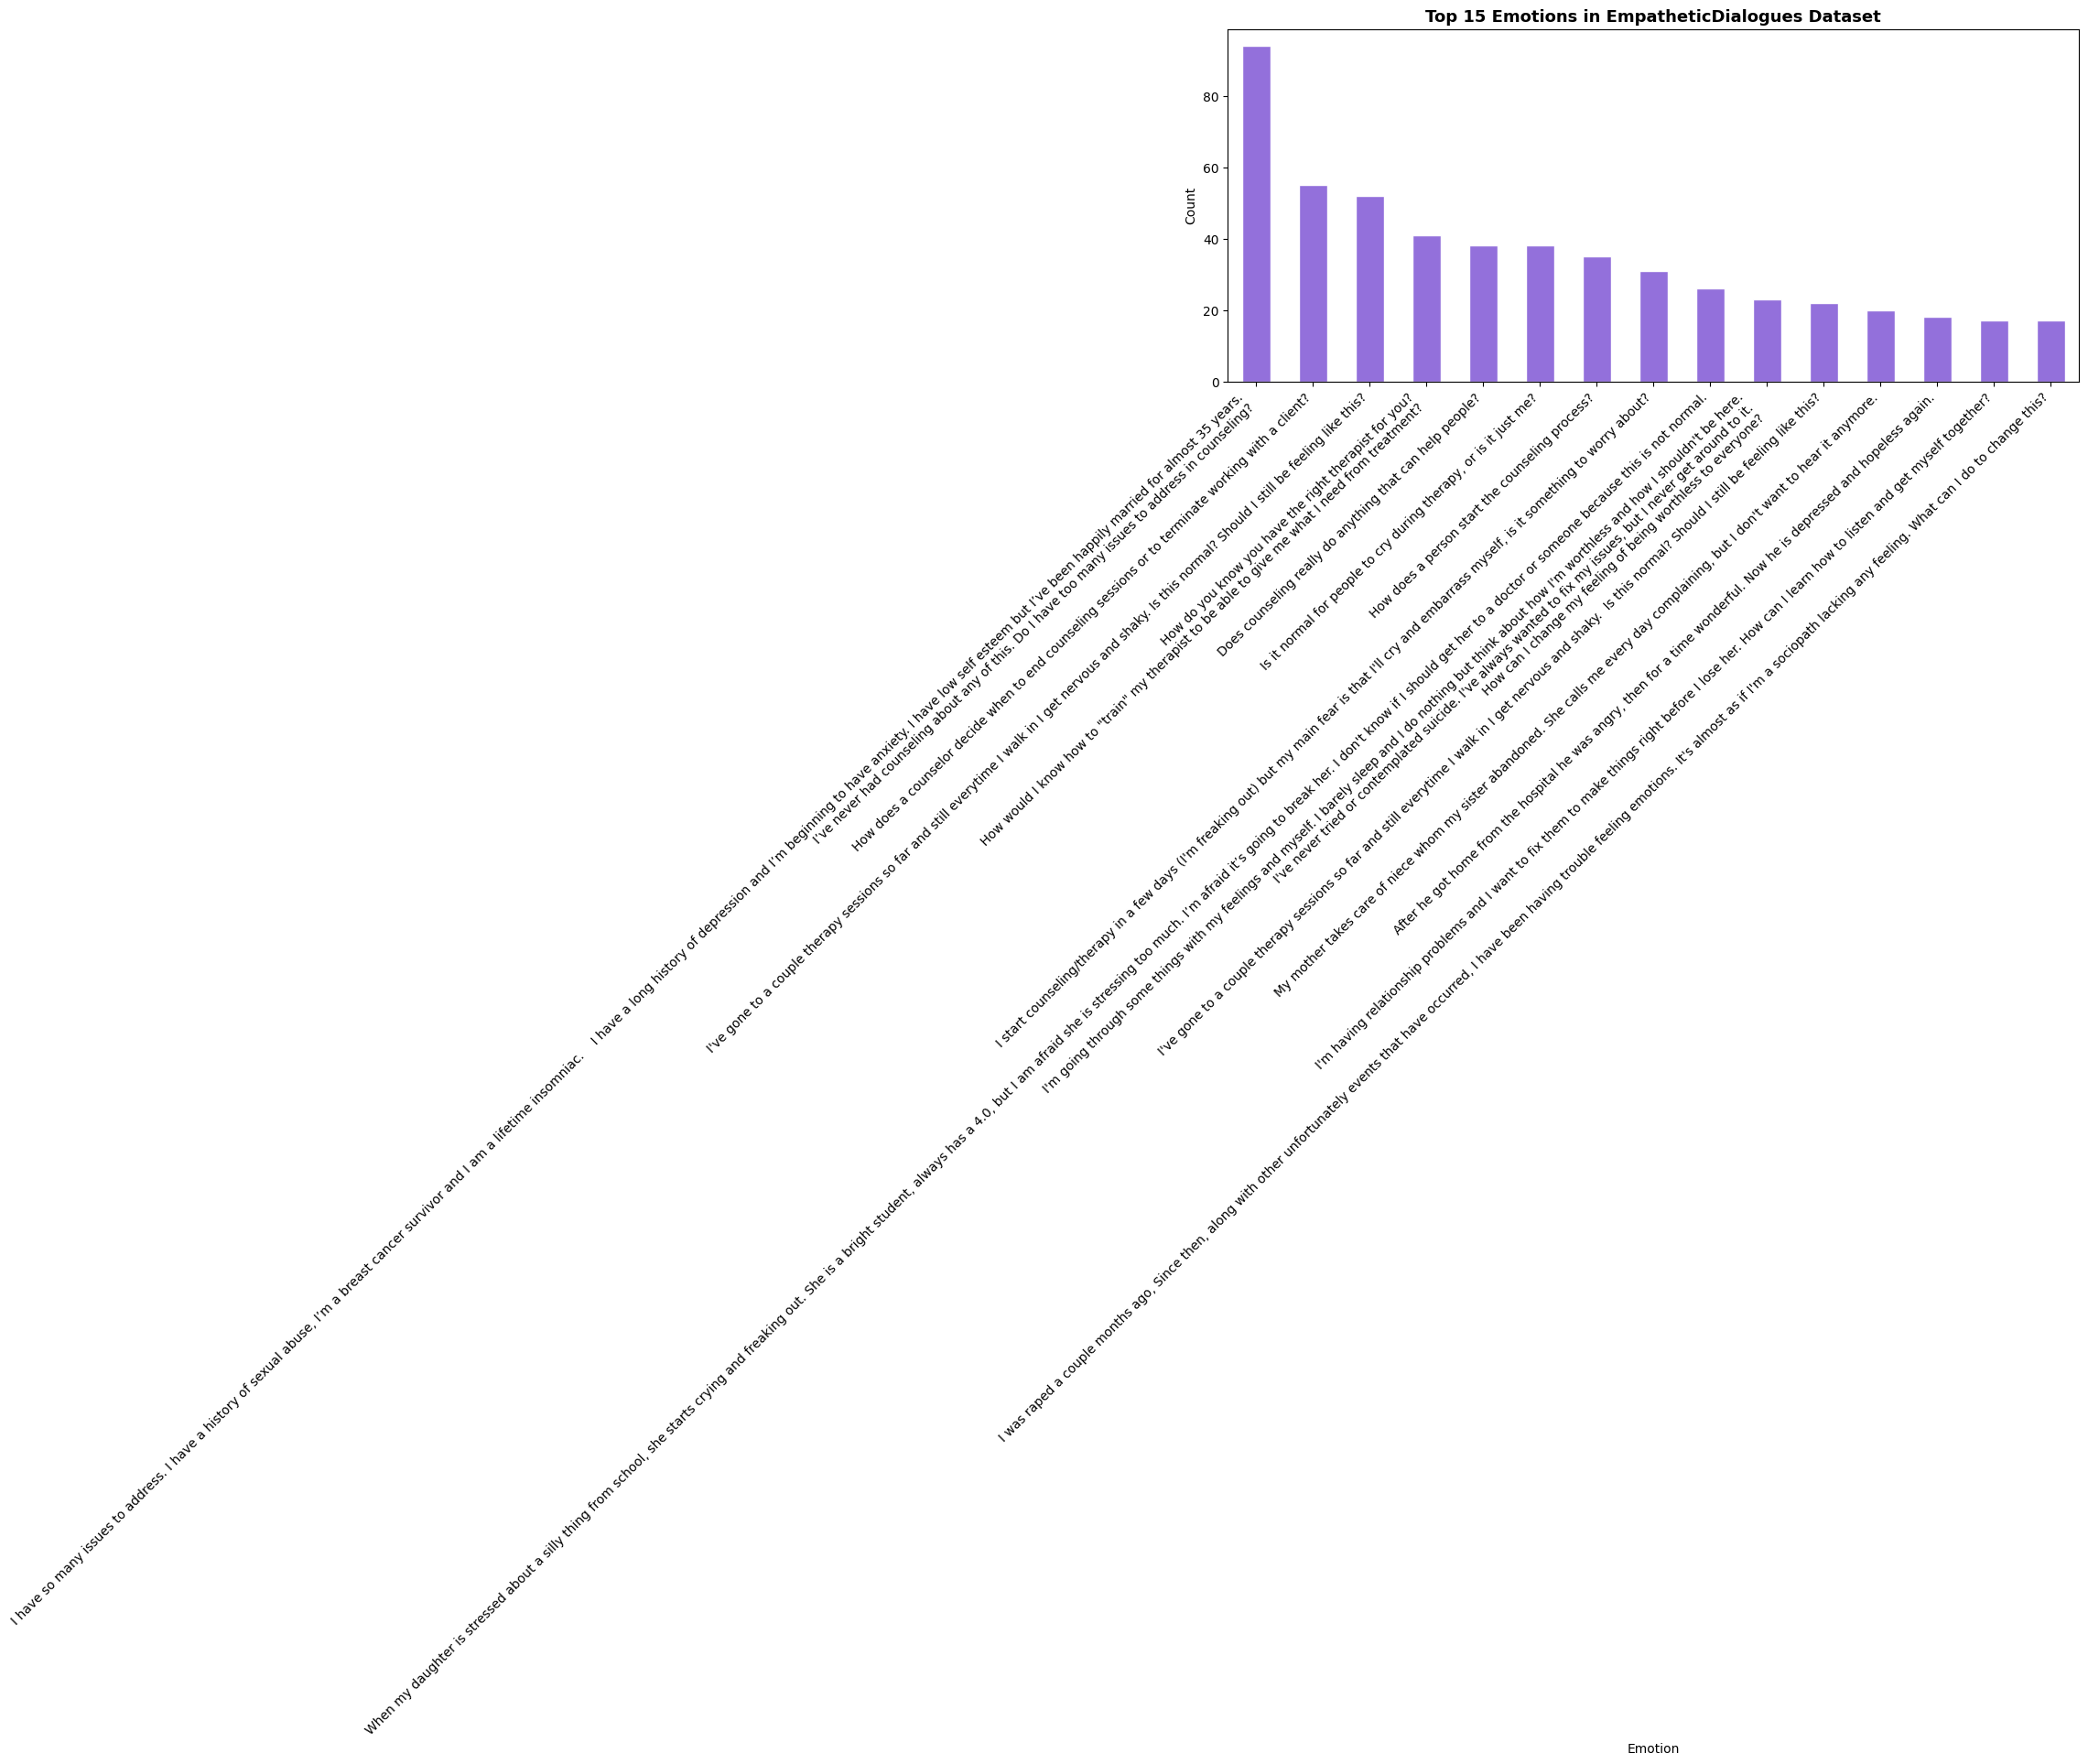

Total unique emotions: 995


In [ ]:
# Show the different emotions in the dataset
import matplotlib.pyplot as plt
import pandas as pd

# Get the first column name automatically (works with any dataset)
emotion_col = dataset['train'].column_names[0]
print(f"Using column: '{emotion_col}' for emotions")

emotions = [sample[emotion_col] for sample in dataset['train']]
emotion_counts = pd.Series(emotions).value_counts().head(15)

plt.figure(figsize=(12, 5))
emotion_counts.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Top 15 Emotions in EmpatheticDialogues Dataset', fontsize=13, fontweight='bold')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total unique emotions: {pd.Series(emotions).nunique()}")

In [ ]:
# Model name — DistilGPT2 is small, fast, and free
MODEL_NAME = "distilgpt2"

print(f"Loading tokenizer and model: {MODEL_NAME}")

# Tokenizer: converts text to numbers the model understands
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Add padding token (GPT2 doesn't have one by default)
tokenizer.pad_token = tokenizer.eos_token

# Load the pre-trained model
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.resize_token_embeddings(len(tokenizer))

print(f"Model loaded!")
print(f"Model parameters: {model.num_parameters():,}")

Loading tokenizer and model: distilgpt2


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!
Model parameters: 81,912,576


In [ ]:
print("Column names:", dataset['train'].column_names)
print()
print("First sample:")
print(dataset['train'][0])

Column names: ['Context', 'Response']

First sample:
{'Context': "I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone?", 'Response': "If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. \xa0Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so saturated with the belief that if someone d

In [ ]:
MAX_LENGTH = 128

def preprocess(examples):
    """
    Formats each dialogue as:
    'Person: [question] Bot: [answer]'
    Then tokenizes it.
    """
    texts = [
        f"Person: {p} Bot: {r}{tokenizer.eos_token}"
        for p, r in zip(examples['Context'], examples['Response'])
    ]

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length'
    )

    tokenized['labels'] = tokenized['input_ids'].copy()
    return tokenized

print("Preprocessing data...")

train_small = dataset['train'].select(range(2000))
val_small   = dataset['train'].select(range(2000, 2200))

train_tokenized = train_small.map(preprocess, batched=True, remove_columns=train_small.column_names)
val_tokenized   = val_small.map(preprocess, batched=True, remove_columns=val_small.column_names)

train_tokenized.set_format('torch')
val_tokenized.set_format('torch')

print(f"Training samples: {len(train_tokenized)}")
print(f"Validation samples: {len(val_tokenized)}")
print("Preprocessing complete!")

Preprocessing data...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Training samples: 2000
Validation samples: 200
Preprocessing complete!


In [ ]:
# Data collator handles padding during training
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False   # we are doing causal LM, not masked LM
)

# Training configuration
training_args = TrainingArguments(
    output_dir='./mental_health_bot',
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=50,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',        # ← renamed from evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to='none'
)

# Create the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator
)

# Start training!
print("Starting fine-tuning...")
print("This may take a few minutes. Please wait...")
trainer.train()

print("Fine-tuning complete!")

# Save the fine-tuned model
model.save_pretrained('./mental_health_bot')
tokenizer.save_pretrained('./mental_health_bot')
print("Model saved to './mental_health_bot'")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting fine-tuning...
This may take a few minutes. Please wait...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,2.948295,2.841228


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Fine-tuning complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to './mental_health_bot'


## Step 6: Build the Response Function

In [ ]:
def generate_response(user_input, max_length=150):
    """
    Takes user input and generates an empathetic response
    using the fine-tuned model.
    """

    # Format input the same way we formatted training data
    prompt = f"Person: {user_input} Bot:"

    # Tokenize the input
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=100
    )

    # Generate response
    with torch.no_grad():
        output = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=80,
            do_sample=True,
            temperature=0.8,         # a bit of creativity
            top_p=0.9,               # nucleus sampling
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.3   # avoid repeating same words
        )

    # Decode: convert numbers back to text
    full_text = tokenizer.decode(output[0], skip_special_tokens=True)

    # Extract only the bot's response (after 'Bot:')
    if 'Bot:' in full_text:
        response = full_text.split('Bot:')[-1].strip()
    else:
        response = full_text

    return response


print("Response function ready!")

Response function ready!


In [ ]:
# ---- Test with sample mental health queries ----

test_inputs = [
    "I have been feeling really stressed lately and don't know what to do.",
    "I feel so anxious before my exams. I can't sleep properly.",
    "I am overwhelmed with everything going on in my life.",
    "I feel lonely and like nobody understands me."
]

print("=" * 58)
print("  MENTAL HEALTH SUPPORT CHATBOT — TEST RESPONSES")
print("=" * 58)

for user_msg in test_inputs:
    print(f"\nPerson: {user_msg}")
    print("-" * 40)
    bot_reply = generate_response(user_msg)
    print(f"Bot: {bot_reply}")
    print()

  MENTAL HEALTH SUPPORT CHATBOT — TEST RESPONSES

Person: I have been feeling really stressed lately and don't know what to do.
----------------------------------------
Bot: I think it is time for us all come together in a healthy, honest manner... You can find out if you are willing or able (or very anxious) yourself that your therapist will be happy with whatever way they want but not afraid of anything new coming from the show because nothing has happened so far this season!  It's worth mentioning at least one thing which makes me sad about having


Person: I feel so anxious before my exams. I can't sleep properly.
----------------------------------------
Bot: You have the right therapist for you, and one that is able to get over your anxiety levels from both therapists themselves! It's a good idea if they provide guidance on how we're feeling about our stress or any of these issues during class with each other - let them know what things are going on at school (or in classes) after

In [ ]:
# ---- Interactive Mental Health Support Chat ----

print("=" * 58)
print("  Mental Health Support Chatbot")
print("  I'm here to listen and support you.")
print("  Type 'quit' to exit.")
print("=" * 58)
print()
print("DISCLAIMER: This chatbot is NOT a replacement for")
print("professional mental health care. If you are in")
print("crisis, please reach out to a professional.")
print()

while True:
    user_input = input("You: ").strip()

    if user_input.lower() in ['quit', 'exit', 'bye']:
        print("Bot: Take care of yourself. Remember, it's okay to ask for help. Goodbye!")
        break

    if not user_input:
        print("Bot: I'm here. Feel free to share whatever is on your mind.")
        continue

    response = generate_response(user_input)
    print(f"Bot: {response}")
    print()

  Mental Health Support Chatbot
  I'm here to listen and support you.
  Type 'quit' to exit.

DISCLAIMER: This chatbot is NOT a replacement for
professional mental health care. If you are in
crisis, please reach out to a professional.

You: quit
Bot: Take care of yourself. Remember, it's okay to ask for help. Goodbye!
